# Asignación de Operarios a Máquinas — ScheduleIt! Factory

Modelo de **programación lineal entera** (PuLP) para asignar 30 operarios a 10 máquinas distribuidas en 3 zonas de una planta industrial.

**Objetivo:** Maximizar las horas productivas de las zonas de Mezcla y Envasado, penalizando las capacitaciones necesarias.

**Zonas y máquinas:**
- **Abastecimiento** ($J_A$): A1, A2, A3
- **Mezcla** ($J_M$): M1, M2, M3
- **Envasado** ($J_E$): L1, L2, L3, L4

Los datos se consumen desde la API REST de `server.py`.

In [1]:
#!pip install requests pulp

In [2]:
import requests
import pandas as pd
from pulp import *
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

BASE_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "IO-TOKEN-GRP1-2025"}  # Cambiar según grupo

## Obtención de Datos desde la API

In [3]:
# Fetch todos los operarios (paginado)
operarios = []
page = 1
while True:
    r = requests.get(f"{BASE_URL}/operarios", headers=HEADERS, params={"page": page, "page_size": 10})
    r.raise_for_status()
    data = r.json()
    operarios.extend(data["data"])
    if page >= data["total_pages"]:
        break
    page += 1

print(f"Total operarios: {len(operarios)}")
df_op = pd.DataFrame(operarios)
df_op.head(10)

Total operarios: 30


,id,habilidades,grupo
0,1,"[M1, L3, L4]",3
1,2,"[M1, M2, L2, L4]",1
2,3,[M1],3
3,4,"[A, L1, L3]",1
4,5,"[M1, L4]",2
5,6,"[M3, L1, L2]",3
6,7,"[M2, L4]",2
7,8,"[M3, L3]",2
8,9,"[L3, L4]",1
9,10,"[M1, L1]",1


In [4]:
# Fetch procesos (no paginado) — confirmar duración capacitación = 8h
r = requests.get(f"{BASE_URL}/procesos", headers=HEADERS)
r.raise_for_status()
procesos = r.json()["procesos"]

for p in procesos:
    print(f"{p['codigo']:10s} | {p['nombre']:35s} | {p['duracion_hs']}h")

cap = next(p for p in procesos if p["codigo"] == "CAP")
DURACION_CAP = cap["duracion_hs"]
print(f"\nDuración capacitación: {DURACION_CAP}h")

LIMP       | Limpieza                            | 6h
CAP        | Capacitación                        | 8h
FMT_CIR    | Cambio de Formato a Círculo         | 4h
FMT_CUA    | Cambio de Formato a Cuadrado        | 6h

Duración capacitación: 8h


## Configuración de Partida

#### {Parametros}

Cada partida del juego se configura tirando dados:
- **1 dado** → grupo asignado a Mezcla (1-2→grupo 1, 3-4→grupo 2, 5-6→grupo 3)
- **2 dados** → la suma indica cuántos operarios están ausentes (se eligen al azar)

Los valores por defecto corresponden al ejemplo del PDF: grupo mezcla = 3, ausentes = {10, 14, 19, 21, 24}.

In [5]:
# ============================================================
# PARÁMETROS DE PARTIDA (modificar según tirada de dados)
# ============================================================
grupo_M = 2                        # Grupo asignado a Mezcla (1, 2 o 3)
ausentes = {28,29} #{10, 14}        # IDs de operarios ausentes
# ============================================================

print(f"Grupo asignado a Mezcla: {grupo_M}")
print(f"Operarios ausentes ({len(ausentes)}): {sorted(ausentes)}")

Grupo asignado a Mezcla: 2
Operarios ausentes (2): [28, 29]


## Conjuntos y Parámetros del Modelo

In [6]:
# Conjuntos de máquinas por zona
J_A = ["A1", "A2", "A3"]
J_M = ["M1", "M2", "M3"]
J_E = ["L1", "L2", "L3", "L4"]
J = J_A + J_M + J_E  # Todas las máquinas

# Conjunto de operarios (IDs)
I = [op["id"] for op in operarios]

# Dotación completa y mínima por máquina
q_full = {"A1": 1, "A2": 1, "A3": 1,
          "M1": 2, "M2": 2, "M3": 2,
          "L1": 7, "L2": 5, "L3": 3, "L4": 3}

q_min  = {"A1": 1, "A2": 1, "A3": 1,
          "M1": 1, "M2": 1, "M3": 1,
          "L1": 6, "L2": 4, "L3": 2, "L4": 2}

# Grupos de operarios
grupos_op = {op["id"]: op["grupo"] for op in operarios}

print("Máquinas:", J)
print("Operarios disponibles:", len([i for i in I if i not in ausentes]))
print("Operarios ausentes:", len(ausentes))

Máquinas: ['A1', 'A2', 'A3', 'M1', 'M2', 'M3', 'L1', 'L2', 'L3', 'L4']
Operarios disponibles: 28
Operarios ausentes: 2


![Distribución de máquinas](data/maquinas.png)

In [7]:
# Matriz de habilidades: hab[i][j] = 1 si operario i puede operar máquina j
# Mapping: "A" → A1,A2,A3; "M1"→M1; "L1"→L1; etc.

hab = {}
for op in operarios:
    i = op["id"]
    hab[i] = {}
    for j in J:
        hab[i][j] = 0
    for skill in op["habilidades"]:
        if skill == "A":
            for j in J_A:
                hab[i][j] = 1
        elif skill in J:
            hab[i][skill] = 1

# Verificar: mostrar cuántos operarios pueden operar cada máquina
for j in J:
    count = sum(hab[i][j] for i in I)
    print(f"  {j}: {count} operarios habilitados")

  A1: 9 operarios habilitados
  A2: 9 operarios habilitados
  A3: 9 operarios habilitados
  M1: 9 operarios habilitados
  M2: 10 operarios habilitados
  M3: 7 operarios habilitados
  L1: 9 operarios habilitados
  L2: 9 operarios habilitados
  L3: 13 operarios habilitados
  L4: 12 operarios habilitados


In [8]:
import pandas as pd

# Crear y mostrar matriz de habilidades como DataFrame
# Mostrar la matriz de habilidades como un DataFrame
df_hab = pd.DataFrame.from_dict(hab, orient='index')
df_hab.head(10)

,A1,A2,A3,M1,M2,M3,L1,L2,L3,L4
1,0,0,0,1,0,0,0,0,1,1
2,0,0,0,1,1,0,0,1,0,1
3,0,0,0,1,0,0,0,0,0,0
4,1,1,1,0,0,0,1,0,1,0
5,0,0,0,1,0,0,0,0,0,1
6,0,0,0,0,0,1,1,1,0,0
7,0,0,0,0,1,0,0,0,0,1
8,0,0,0,0,0,1,0,0,1,0
9,0,0,0,0,0,0,0,0,1,1
10,0,0,0,1,0,0,1,0,0,0


## Modelo PuLP

**Variables de decisión:**
- $x_{ij} \in \{0,1\}$: operario $i$ asignado a máquina $j$
- $y_j \in \{0,1\}$: máquina $j$ opera a dotación completa (40h)
- $y^{min}_j \in \{0,1\}$: máquina $j$ opera a dotación mínima (32h)
- $c_{ij} \in \{0,1\}$: operario $i$ se capacita para máquina $j$

**Función objetivo:**

$$\max \sum_{j \in J_M \cup J_E} \left(40 \cdot y_j + 32 \cdot y^{min}_j\right) - 8 \cdot \sum_{i \in I}\sum_{j \in J} c_{ij}$$

**Restricciones:**
1. Cada operario asignado a máximo 1 máquina
2. No más operarios que puestos ($\leq q^{full}_j$)
3. Ausentes no se asignan
4. Habilidad o capacitación ($x_{ij} \leq hab_{ij} + c_{ij}$)
5. Activación completa ($\sum_i x_{ij} \geq q^{full}_j \cdot y_j$)
6. Activación mínima ($\sum_i x_{ij} \geq q^{min}_j \cdot y^{min}_j$)
7. Exclusividad ($y_j + y^{min}_j \leq 1$)
8. Precedencia $y_{A1} = y_{M1} + y^{min}_{M1}$
9. Precedencia $y_{A2} = y_{M2} + y^{min}_{M2}$
10. Precedencia $y_{A3} = y_{M3} + y^{min}_{M3}$
11. Grupo mezcla no va a envasado
12. Otros grupos no van a mezcla ni abastecimiento
13. Máximo 1 capacitación

![Restricciones](data/restricciones.png)

#### Creamos el modelo y las vars de decisión

In [9]:
# Crear modelo
modelo = LpProblem("Asignacion_Operarios", LpMaximize)

# =======================
# Variables de decisión (binarias)
# =======================

# Operario i asignado a máquina j
x = LpVariable.dicts("x", [(i, j) for i in I for j in J], cat="Binary")

# Máquina j opera a dotación completa
y = LpVariable.dicts("y", J, cat="Binary")

# Máquina j opera a dotación mínima
y_min = LpVariable.dicts("y_min", J, cat="Binary")

# Operario i se capacita para
c = LpVariable.dicts("c", [(i, j) for i in I for j in J], cat="Binary")

In [10]:
# Función objetivo: max horas productivas (mezcla + envasado) - costo capacitaciones
J_prod = J_M + J_E  # Solo mezcla y envasado generan horas productivas

modelo += (
    lpSum(40 * y[j] + 32 * y_min[j] for j in J_prod)
    - DURACION_CAP * lpSum(c[i, j] for i in I for j in J),
    "FO_horas_productivas"
)

# ![Función objetivo](data/funcion_obj.png)

#### Restricciones

In [11]:
# R1: Cada operario (i en I) asignado a máximo 1 máquina (j en J)
for i in I:
    modelo += lpSum(x[i, j] for j in J) <= 1, f"R1_max1maq_{i}"

# R2: No más operarios que puestos (dotación completa como cota superior para cada máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) <= q_full[j], f"R2_capacidad_{j}"

# R3: Ausentes no se asignan (i en ausentes, j en J)
for i in ausentes:
    for j in J:
        modelo += x[i, j] == 0, f"R3_ausente_{i}_{j}"

# R4: Solo asignar si tiene habilidad o se capacita (operario i en I, máquina j en J)
for i in I:
    for j in J:
        modelo += x[i, j] <= hab[i][j] + c[i, j], f"R4_habilidad_{i}_{j}"

# R5: Activación completa — si y_j=1, necesita q_full operarios (máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) >= q_full[j] * y[j], f"R5_full_{j}"

# R6: Activación mínima — si y_min_j=1, necesita q_min operarios (máquina j en J)
for j in J:
    modelo += lpSum(x[i, j] for i in I) >= q_min[j] * y_min[j], f"R6_min_{j}"

# R7: Exclusividad — una máquina no puede estar full y min a la vez
for j in J:
    modelo += y[j] + y_min[j] <= 1, f"R7_exclusividad_{j}"

print(f"Restricciones R1-R7 agregadas")

Restricciones R1-R7 agregadas


In [12]:
# R8-R10: Precedencia — abastecimiento Ak activa si y solo si mezcla Mk opera
# y_Ak = y_Mk + y_min_Mk  (si Mk opera en cualquier modo, Ak debe estar activa full)
for k in range(3):
    ak = J_A[k]  # A1, A2, A3
    mk = J_M[k]  # M1, M2, M3
    modelo += y[ak] == y[mk] + y_min[mk], f"R{8+k}_precedencia_{ak}_{mk}"

# R11: Prohibición de asignación de operarios del grupo de Mezcla a Envasado.
# Para cada operario i, si pertenece al grupo de Mezcla (grupo_M),
# entonces no se le puede asignar a ninguna máquina de Envasado (todas en J_E).
for i in I:
    if grupos_op[i] == grupo_M:
        for j in J_E:
            # Restricción: los operarios de grupo Mezcla no pueden operar máquinas de Envasado.
            modelo += x[i, j] == 0, f"R11_grpM_no_env_{i}_{j}"

# R12: Prohibición de asignación de operarios de otros grupos a Mezcla o Abastecimiento.
# Para cada operario i, si NO pertenece al grupo de Mezcla (grupo_M),
# entonces no se le puede asignar ni a máquinas de Mezcla (J_M) ni de Abastecimiento (J_A).
for i in I:
    if grupos_op[i] != grupo_M:
        for j in J_M + J_A:
            # Restricción: operarios fuera del grupo Mezcla no pueden operar ni Mezcla ni Abastecimiento.
            modelo += x[i, j] == 0, f"R12_otros_no_mezcla_{i}_{j}"

# R13: Máximo 1 capacitación en TOTAL (no por operario)
modelo += lpSum(c[i, j] for i in I for j in J) <= 1, "R13_max1cap_total"

print(f"Restricciones R8-R13 agregadas")
print(f"Total restricciones: {modelo.numConstraints()}")
print(f"Total variables: {modelo.numVariables()}")

Restricciones R8-R13 agregadas
Total restricciones: 554
Total variables: 620


## Resolución

In [13]:
# Resolver
modelo.solve(PULP_CBC_CMD(msg=0))

print(f"Estado: {LpStatus[modelo.status]}")
print(f"Valor objetivo (horas productivas netas): {value(modelo.objective)}")

Estado: Optimal
Valor objetivo (horas productivas netas): 224.0


## Resultados

In [14]:
# Tabla de asignaciones
asignaciones = []
for i in I:
    for j in J:
        if value(x[i, j]) == 1:
            capacitado = value(c[i, j]) == 1
            zona = "Abastecimiento" if j in J_A else "Mezcla" if j in J_M else "Envasado"
            asignaciones.append({
                "Operario": i,
                "Grupo": grupos_op[i],
                "Máquina": j,
                "Zona": zona,
                "Capacitado": "Sí" if capacitado else "No"
            })

df_asig = pd.DataFrame(asignaciones).sort_values(["Zona", "Máquina", "Operario"])
print(f"Operarios asignados: {len(df_asig)}")
df_asig

Operarios asignados: 23


,Operario,Grupo,Máquina,Zona,Capacitado
13,17,2,A1,Abastecimiento,No
15,20,2,A3,Abastecimiento,Sí
2,4,1,L1,Envasado,No
3,6,3,L1,Envasado,No
6,10,1,L1,Envasado,No
7,11,1,L1,Envasado,No
8,12,3,L1,Envasado,No
14,19,3,L1,Envasado,No
1,2,1,L2,Envasado,No
9,13,3,L2,Envasado,No


In [15]:
# Estado de máquinas
print(f"{'Máquina':<10} {'Estado':<15} {'Operarios':<8} {'q_min':<6} {'q_full':<6} {'Horas'}")
print("-" * 60)
for j in J:
    n_ops = int(sum(value(x[i, j]) for i in I))
    if value(y[j]) == 1:
        estado = "FULL (40h)"
        horas = 40
    elif value(y_min[j]) == 1:
        estado = "MÍNIMA (32h)"
        horas = 32
    else:
        estado = "INACTIVA"
        horas = 0
    zona = "A" if j in J_A else "M" if j in J_M else "E"
    print(f"  {j:<8} {estado:<15} {n_ops:<8} {q_min[j]:<6} {q_full[j]:<6} {horas if j in J_prod else '-'}")

Máquina    Estado          Operarios q_min  q_full Horas
------------------------------------------------------------
  A1       FULL (40h)      1        1      1      -
  A2       INACTIVA        0        1      1      -
  A3       FULL (40h)      1        1      1      -
  M1       FULL (40h)      2        1      2      40
  M2       INACTIVA        0        1      2      0
  M3       FULL (40h)      2        1      2      40
  L1       MÍNIMA (32h)    6        6      7      32
  L2       FULL (40h)      5        4      5      40
  L3       FULL (40h)      3        2      3      40
  L4       FULL (40h)      3        2      3      40


In [16]:
# Desglose de horas productivas
horas_mezcla = sum(40 * value(y[j]) + 32 * value(y_min[j]) for j in J_M)
horas_envasado = sum(40 * value(y[j]) + 32 * value(y_min[j]) for j in J_E)
costo_cap = DURACION_CAP * sum(value(c[i, j]) for i in I for j in J)
n_cap = int(sum(value(c[i, j]) for i in I for j in J))

print(f"Horas productivas Mezcla:   {int(horas_mezcla)}h")
print(f"Horas productivas Envasado: {int(horas_envasado)}h")
print(f"Capacitaciones realizadas:  {n_cap} (costo: {int(costo_cap)}h)")
print(f"────────────────────────────────")
print(f"TOTAL NETO:                 {int(horas_mezcla + horas_envasado - costo_cap)}h")

Horas productivas Mezcla:   80h
Horas productivas Envasado: 152h
Capacitaciones realizadas:  1 (costo: 8h)
────────────────────────────────
TOTAL NETO:                 224h


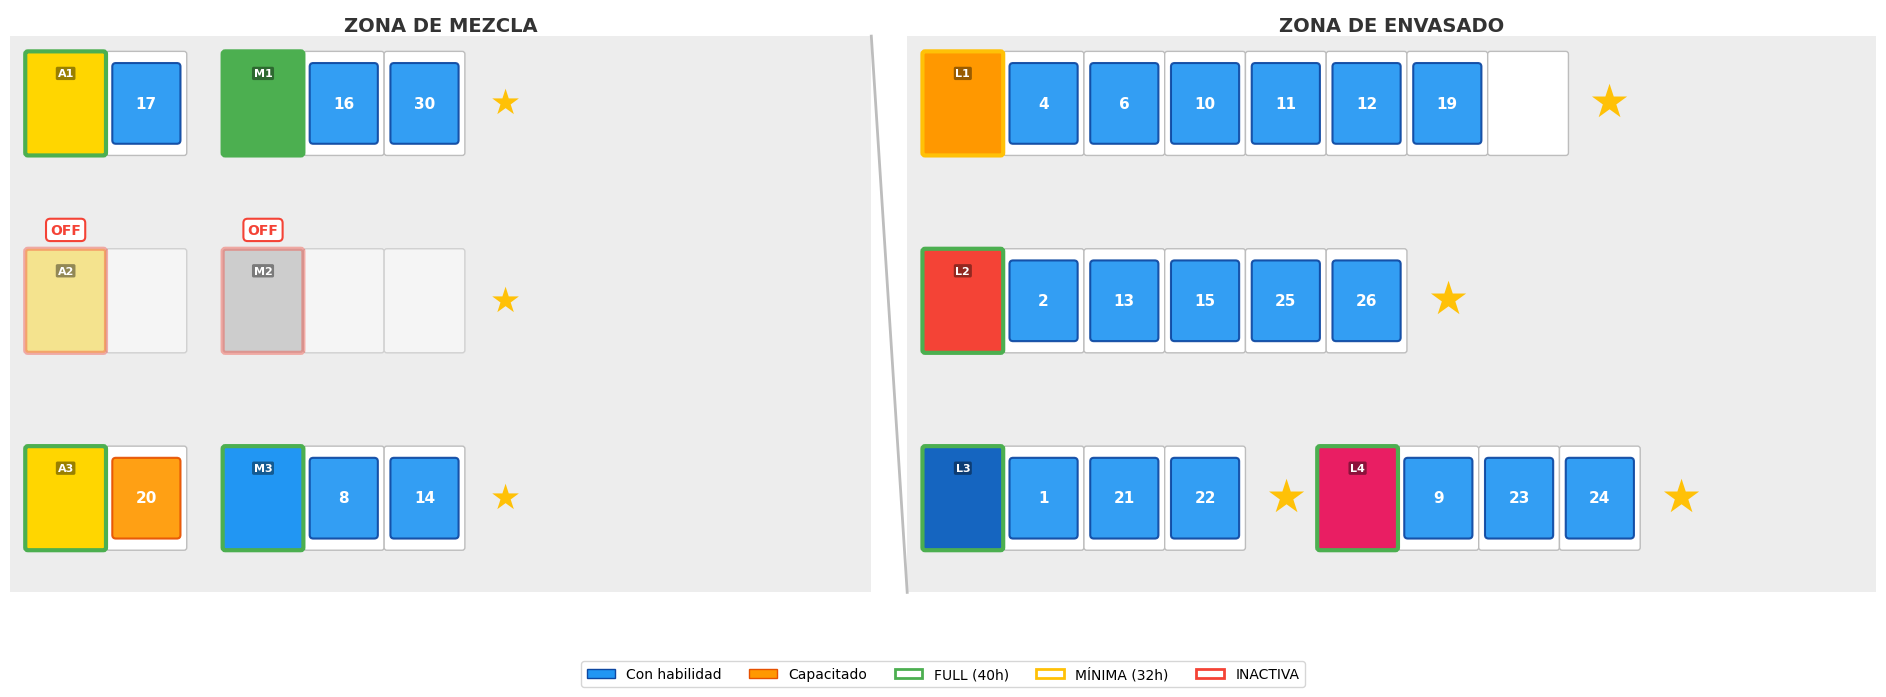

In [17]:
# Visualización de planta generada con matplotlib
from matplotlib.patches import FancyBboxPatch, Patch, Rectangle
                                                                                                                                                                                        
fig, ax = plt.subplots(figsize=(20, 7))                                                                                                                                                   
ax.set_xlim(0, 104)                                                                                                                                                                       
ax.set_ylim(-2, 34)                                                                                                                                                                       
ax.set_aspect('equal')                                                                                                                                                                    
ax.axis('off')
                                                                                                                                                                                        
MACH_COLORS = { 
    "A1": "#FFD600", "A2": "#FFD600", "A3": "#FFD600",
    "M1": "#4CAF50", "M2": "#9E9E9E", "M3": "#2196F3",                                                                                                                                    
    "L1": "#FF9800", "L2": "#F44336", "L3": "#1565C0", "L4": "#E91E63",                                                                                                                   
}                                                                                                                                                                                         
BADGE_SKILL = "#2196F3"                                                                                                                                                                   
BADGE_CAP   = "#FF9800"                                                                                                                                                                   
STATUS_FULL = "#4CAF50"                                                                                                                                                                   
STATUS_MIN  = "#FFC107"
STATUS_INACT = "#F44336"                                                                                                                                                                  
                
row_y = [26, 15, 4]                                                                                                                                                                       
box_w, box_h = 4.2, 5.5
gap = 0.3                                                                                                                                                                                 
                
ax.add_patch(Rectangle((0, 1.5), 48, 31, facecolor="#EDEDED", edgecolor="none", zorder=0))                                                                                                
ax.add_patch(Rectangle((50, 1.5), 54, 31, facecolor="#EDEDED", edgecolor="none", zorder=0))
ax.text(24, 32.8, "ZONA DE MEZCLA", ha='center', fontsize=14, fontweight='bold', color="#333")                                                                                            
ax.text(77, 32.8, "ZONA DE ENVASADO", ha='center', fontsize=14, fontweight='bold', color="#333")                                                                                          
                                                                                                                                                                                        
layout = [                                                                                                                                                                                
    ("A1", 0, 1),  ("M1", 0, 12),                                                                                                                                                         
    ("A2", 1, 1),  ("M2", 1, 12),                                                                                                                                                         
    ("A3", 2, 1),  ("M3", 2, 12),
    ("L1", 0, 51), ("L2", 1, 51),                                                                                                                                                         
    ("L3", 2, 51), ("L4", 2, 73),
]                                                                                                                                                                                         
                
machine_ops = {}                                                                                                                                                                          
for j in J:     
    machine_ops[j] = [(i, value(c[i, j]) == 1) for i in I if value(x[i, j]) == 1]                                                                                                         
                                                                                                                                                                                        
def get_status(j):                                                                                                                                                                        
    if value(y[j]) == 1:                                                                                                                                                                  
        return "full", STATUS_FULL                                                                                                                                                        
    elif value(y_min[j]) == 1:
        return "min", STATUS_MIN                                                                                                                                                          
    else:       
        return "off", STATUS_INACT

def draw_machine(ax, label, x0, y0, color, status_color, is_off=False):                                                                                                                   
    rect = FancyBboxPatch((x0, y0), box_w, box_h,
        boxstyle="round,pad=0.15", facecolor=color, edgecolor=status_color,                                                                                                               
        linewidth=3, zorder=2, alpha=0.4 if is_off else 1.0)                                                                                                                              
    ax.add_patch(rect)
    ax.text(x0 + box_w/2, y0 + box_h - 0.8, label,                                                                                                                                        
        ha='center', va='top', fontsize=8, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='#00000066', edgecolor='none'),                                                                                                    
        zorder=3)                                                                                                                                                                         
    if is_off:                                                                                                                                                                            
        ax.text(x0 + box_w/2, y0 + box_h + 1.2, "OFF",                                                                                                                                    
            ha='center', va='center', fontsize=10, fontweight='bold', color=STATUS_INACT,                                                                                                 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=STATUS_INACT, linewidth=1.5),                                                                                
            zorder=5)                                                                                                                                                                     
                                                                                                                                                                                        
def draw_slot(ax, x0, y0, op_id=None, is_cap=False, dimmed=False):                                                                                                                        
    rect = FancyBboxPatch((x0, y0), box_w, box_h,
        boxstyle="round,pad=0.15", facecolor='#F5F5F5' if dimmed else 'white',                                                                                                            
        edgecolor='#D0D0D0' if dimmed else '#BDBDBD', linewidth=1, zorder=1)
    ax.add_patch(rect)                                                                                                                                                                    
    if op_id is not None:                                                                                                                                                                 
        color = BADGE_CAP if is_cap else BADGE_SKILL                                                                                                                                      
        edge = "#E65100" if is_cap else "#0D47A1"                                                                                                                                         
        badge = FancyBboxPatch((x0 + 0.4, y0 + 0.7), box_w - 0.8, box_h - 1.4,
            boxstyle="round,pad=0.2", facecolor=color, edgecolor=edge,                                                                                                                    
            linewidth=1.5, alpha=0.5 if dimmed else 0.92, zorder=3)
        ax.add_patch(badge)                                                                                                                                                               
        ax.text(x0 + box_w/2, y0 + box_h/2, str(op_id),
            ha='center', va='center', fontsize=11, fontweight='bold',                                                                                                                     
            color='white', alpha=0.5 if dimmed else 1.0, zorder=4)                                                                                                                        

def draw_star(ax, x0, y0, size=1.0):                                                                                                                                                      
    cx, cy = x0 + box_w/2, y0 + box_h/2
    ax.text(cx, cy, "★", ha='center', va='center',                                                                                                                                        
        fontsize=int(28 * size), color='#FFC107', zorder=2)
                                                                                                                                                                                        
for mach, row_idx, x_start in layout:                                                                                                                                                     
    yb = row_y[row_idx]
    n_full = q_full[mach]                                                                                                                                                                 
    ops = machine_ops[mach]
    status, sc = get_status(mach)
    is_off = (status == "off")
                                                                                                                                                                                        
    draw_machine(ax, mach, x_start, yb, MACH_COLORS[mach], sc, is_off=is_off)                                                                                                             
                                                                                                                                                                                        
    for slot_idx in range(n_full):                                                                                                                                                        
        sx = x_start + (slot_idx + 1) * (box_w + gap)
        if slot_idx < len(ops):                                                                                                                                                           
            op_id, is_cap = ops[slot_idx]
            draw_slot(ax, sx, yb, op_id, is_cap, dimmed=is_off)                                                                                                                           
        else:                                                                                                                                                                             
            draw_slot(ax, sx, yb, dimmed=is_off)
                                                                                                                                                                                        
    # Estrella solo para M y L (no para A)
    if mach not in J_A:                                                                                                                                                                   
        star_x = x_start + (n_full + 1) * (box_w + gap)                                                                                                                                   
        star_size = 1.2 if mach in J_E else 0.9                                                                                                                                           
        draw_star(ax, star_x, yb, star_size)                                                                                                                                              
                                                                                                                                                                                        
ax.plot([48, 50], [32.5, 1.5], color='#BDBDBD', linewidth=2, linestyle='-', zorder=1)                                                                                                     
                                                                                                                                                                                        
legend_elements = [                                                                                                                                                                       
    Patch(facecolor=BADGE_SKILL, edgecolor="#0D47A1", label="Con habilidad"),
    Patch(facecolor=BADGE_CAP, edgecolor="#E65100", label="Capacitado"),                                                                                                                  
    Patch(facecolor="none", edgecolor=STATUS_FULL, linewidth=2, label="FULL (40h)"),
    Patch(facecolor="none", edgecolor=STATUS_MIN, linewidth=2, label="MÍNIMA (32h)"),                                                                                                     
    Patch(facecolor="none", edgecolor=STATUS_INACT, linewidth=2, label="INACTIVA"),                                                                                                       
]                                                                                                                                                                                         
ax.legend(handles=legend_elements, loc="lower center", bbox_to_anchor=(0.5, -0.06),                                                                                                       
        ncol=5, fontsize=10, frameon=True)                                                                                                                                              
                                                                                                                                                                                        
plt.tight_layout()
plt.show()                                                                

In [18]:
df_asig

,Operario,Grupo,Máquina,Zona,Capacitado
13,17,2,A1,Abastecimiento,No
15,20,2,A3,Abastecimiento,Sí
2,4,1,L1,Envasado,No
3,6,3,L1,Envasado,No
6,10,1,L1,Envasado,No
7,11,1,L1,Envasado,No
8,12,3,L1,Envasado,No
14,19,3,L1,Envasado,No
1,2,1,L2,Envasado,No
9,13,3,L2,Envasado,No


In [19]:
# Estado de máquinas
print(f"{'Máquina':<10} {'Estado':<15} {'Operarios':<8} {'q_min':<6} {'q_full':<6} {'Horas'}")
print("-" * 60)
for j in J:
    n_ops = int(sum(value(x[i, j]) for i in I))
    if value(y[j]) == 1:
        estado = "FULL (40h)"
        horas = 40
    elif value(y_min[j]) == 1:
        estado = "MÍNIMA (32h)"
        horas = 32
    else:
        estado = "INACTIVA"
        horas = 0
    zona = "A" if j in J_A else "M" if j in J_M else "E"
    print(f"  {j:<8} {estado:<15} {n_ops:<8} {q_min[j]:<6} {q_full[j]:<6} {horas if j in J_prod else '-'}")

Máquina    Estado          Operarios q_min  q_full Horas
------------------------------------------------------------
  A1       FULL (40h)      1        1      1      -
  A2       INACTIVA        0        1      1      -
  A3       FULL (40h)      1        1      1      -
  M1       FULL (40h)      2        1      2      40
  M2       INACTIVA        0        1      2      0
  M3       FULL (40h)      2        1      2      40
  L1       MÍNIMA (32h)    6        6      7      32
  L2       FULL (40h)      5        4      5      40
  L3       FULL (40h)      3        2      3      40
  L4       FULL (40h)      3        2      3      40
